# __Project Title: Fast Food Consumption and Health Impact Prediction Using Random Forest__

## __Problem Statement:__
- Fast food consumption has increased due to busy lifestyles and easy availability, which can negatively affect health. This project analyzes a fast-food consumption dataset to understand how dietary habits and lifestyle factors influence overall health and uses machine learning to predict an individual's overall health score.

### Objectives:
- Analyze the fast-food consumption dataset to understand health impacts.
- Perform EDA to identify patterns in eating habits and lifestyle.
- Preprocess the data for machine learning.
- Build a model to predict Overall Health Score.
- Evaluate the model using appropriate performance metrics.

### Steps to be followed:
1. Import the required library
2. Load the data
3. Check for null values
4. Analyze the data column distribution
5. Balance the data
6. Encode of the full dataset
7. Split and train the dataset
8. Perform feature scaling on the dataset
9. Compile the model
10. Fit the model
11. Print the model
12. Evaluate the metrics


## Step 1: Import the Required Library
- Import the essential libraries for data manipulation and analysis, such as NumPy and Pandas, and use PyMySQL for database connectivity, LabelEncoder for data preprocessing, and Matplotlib for visualization

In [98]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error, root_mean_squared_error

from sklearn.model_selection import train_test_split, GridSearchCV ,cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.metrics import classification_report ,confusion_matrix,accuracy_score,precision_score,roc_curve,auc
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

## Step 2: Load the Data
- Load a CSV file named **loan_data.xlsx** into a Pandas DataFrame named **df**
- Display the initial few rows of the **df** DataFrame

In [99]:
df=pd.read_csv(r"C:\Users\kpasw\OneDrive\Desktop\Datasets\Data sets\fast_food_consumption_health_impact_dataset.csv")
df

,Age,Gender,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Digestive_Issues,Doctor_Visits_Per_Year,Overall_Health_Score
0,56,Male,1,3153,28.4,4.5,7.8,9,No,7,5
1,46,Male,12,1748,22.8,9.6,6.7,2,No,4,3
2,32,Female,8,3020,21.5,4.0,7.4,2,Yes,7,4
3,25,Female,6,2621,26.8,8.4,6.1,6,No,7,8
4,38,Female,14,2260,18.1,1.9,7.7,7,No,5,4
...,...,...,...,...,...,...,...,...,...,...,...
795,40,Male,6,3244,29.6,9.3,6.0,1,Yes,1,4
796,31,Other,0,2352,24.9,9.2,4.7,7,Yes,0,5
797,41,Other,11,2466,18.3,6.4,4.1,6,No,0,5
798,19,Male,8,3047,27.9,6.3,6.7,2,Yes,8,5


## Step 3:Data Cleaning and Preprocessing

In [100]:
df.shape

(800, 11)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               800 non-null    int64  
 1   Gender                            800 non-null    object 
 2   Fast_Food_Meals_Per_Week          800 non-null    int64  
 3   Average_Daily_Calories            800 non-null    int64  
 4   BMI                               800 non-null    float64
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64
 6   Sleep_Hours_Per_Day               800 non-null    float64
 7   Energy_Level_Score                800 non-null    int64  
 8   Digestive_Issues                  800 non-null    object 
 9   Doctor_Visits_Per_Year            800 non-null    int64  
 10  Overall_Health_Score              800 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 68.9+ KB


In [102]:
df.describe()

,Age,Fast_Food_Meals_Per_Week,Average_Daily_Calories,BMI,Physical_Activity_Hours_Per_Week,Sleep_Hours_Per_Day,Energy_Level_Score,Doctor_Visits_Per_Year,Overall_Health_Score
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,38.802500,6.818750,2554.728750,26.43900,4.938000,6.472875,4.903750,5.648750,4.922500
std,12.055919,4.329183,551.078974,4.94144,2.860272,1.429232,2.587538,3.467045,2.681974
min,18.000000,0.000000,1600.000000,18.00000,0.000000,4.000000,1.000000,0.000000,1.000000
25%,29.000000,3.000000,2084.750000,22.50000,2.400000,5.200000,3.000000,3.000000,3.000000
50%,40.000000,7.000000,2540.500000,26.40000,4.900000,6.500000,5.000000,6.000000,5.000000
75%,49.000000,11.000000,3049.000000,30.62500,7.400000,7.700000,7.000000,9.000000,7.000000
max,59.000000,14.000000,3499.000000,35.00000,10.000000,9.000000,9.000000,11.000000,9.000000


In [103]:
df.isna().sum()

Age                                 0
Gender                              0
Fast_Food_Meals_Per_Week            0
Average_Daily_Calories              0
BMI                                 0
Physical_Activity_Hours_Per_Week    0
Sleep_Hours_Per_Day                 0
Energy_Level_Score                  0
Digestive_Issues                    0
Doctor_Visits_Per_Year              0
Overall_Health_Score                0
dtype: int64

## Step 4: Exploratory Data Analysis (EDA)
- Visualizations are used to understand relationships between variables and battery health.

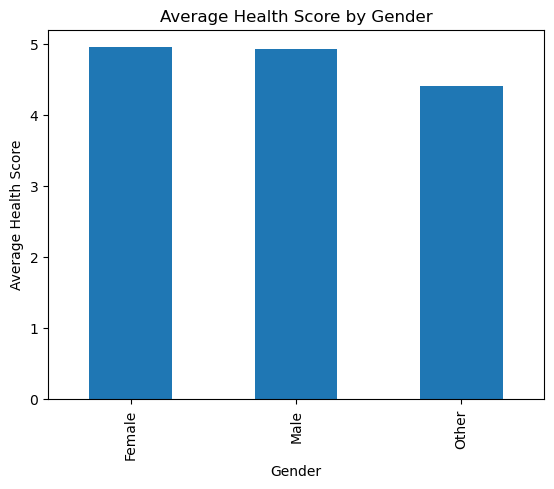

In [104]:
plt.figure()
df.groupby('Gender')['Overall_Health_Score'].mean().plot(kind='bar')
plt.title("Average Health Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Health Score")
plt.show()

### Observation:
- The chart shows that female and male individuals have similar average health scores, while the 'Other' category has a slightly lower average health score compared to the other groups

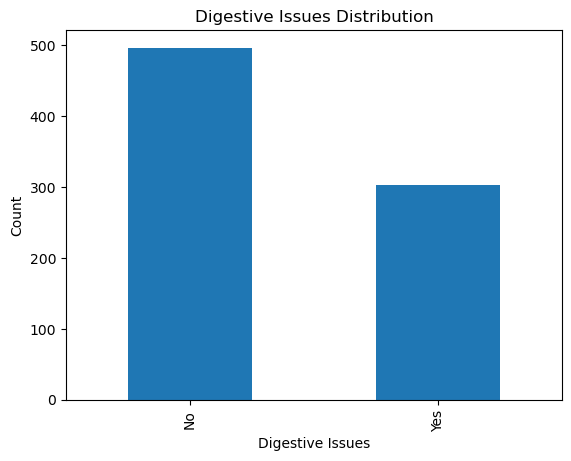

In [105]:
plt.figure()
df['Digestive_Issues'].value_counts().plot(kind='bar')
plt.title("Digestive Issues Distribution")
plt.xlabel("Digestive Issues")
plt.ylabel("Count")
plt.show()

### Observation:
- The chart shows that most individuals do not experience digestive issues, while a smaller portion of people report having digestive problems.

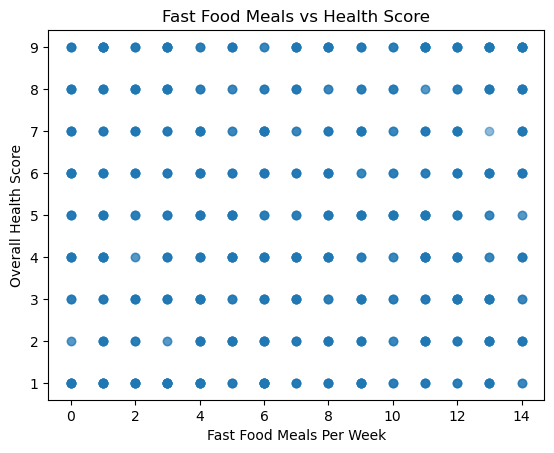

In [106]:
    plt.figure()
    plt.scatter(df['Fast_Food_Meals_Per_Week'], df['Overall_Health_Score'], alpha=0.5)
    plt.title("Fast Food Meals vs Health Score")
    plt.xlabel("Fast Food Meals Per Week")
    plt.ylabel("Overall Health Score")
    plt.show()

### Observation:
- The scatter plot shows that individuals with different levels of fast food consumption have varying health scores, indicating that fast food intake may influence overall health.

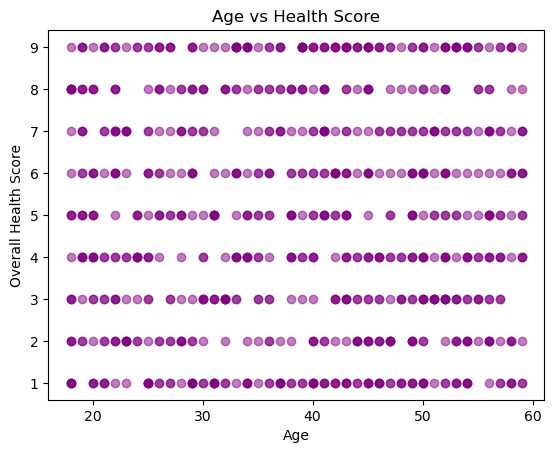

In [107]:
plt.figure()
plt.scatter(df["Age"], df["Overall_Health_Score"], alpha=0.5, color='purple')
plt.title("Age vs Health Score")
plt.xlabel("Age")
plt.ylabel("Overall Health Score")
plt.show()

### Observation:
- The scatter plot shows that health scores vary across different age groups, and there is no clear strong relationship between age and overall health score in the dataset.

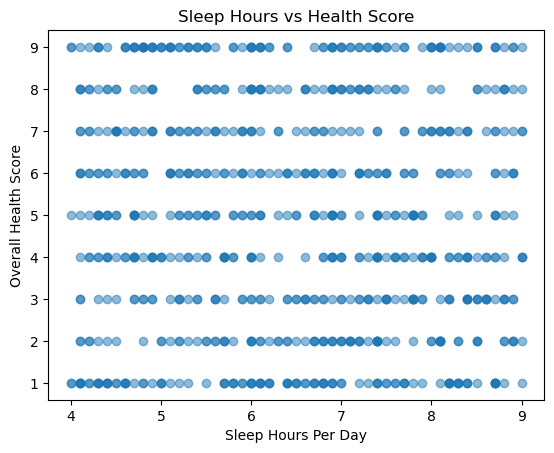

In [108]:
plt.figure()
plt.scatter(df['Sleep_Hours_Per_Day'], df['Overall_Health_Score'], alpha=0.5)
plt.title("Sleep Hours vs Health Score")
plt.xlabel("Sleep Hours Per Day")
plt.ylabel("Overall Health Score")
plt.show()

### Observation:
- The scatter plot shows that individuals with different sleep hours have varying health scores, suggesting that adequate sleep may contribute to better overall health.

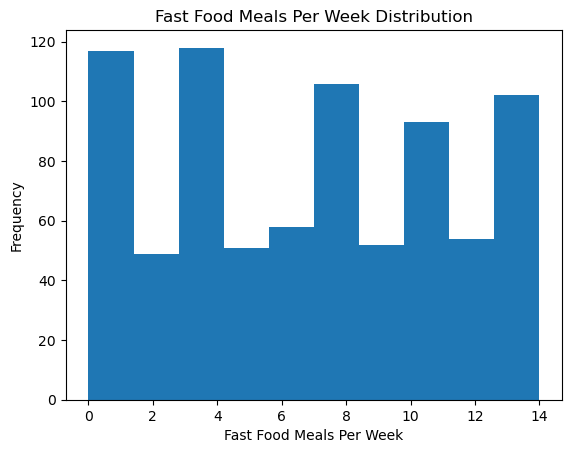

In [109]:
plt.figure()
df['Fast_Food_Meals_Per_Week'].plot(kind='hist', bins=10)
plt.title("Fast Food Meals Per Week Distribution")
plt.xlabel("Fast Food Meals Per Week")
plt.ylabel("Frequency")
plt.show()

### Observation:
- The histogram shows that fast food consumption varies across individuals, with people eating different numbers of fast food meals per week, indicating diverse dietary habits.

### Encoding Categorical Data
-This step prepares the categorical feature for model training.

In [110]:
 label_encoder = LabelEncoder()
categorical_cols=['Digestive_Issues']
for col in categorical_cols:
    df[col] = df[col].astype(str)
    df[col] = label_encoder.fit_transform(df[col])

## Step 5: Feature–Target Separation

In [111]:
x=df.drop(columns=['Overall_Health_Score','Gender'])
y=df['Overall_Health_Score']

### Traing and Testing the Features (Train-Test Splitting)
- Prevents overfitting
- Allows evaluation on unseen data

In [112]:
x_train,x_test,y_train,y_test=train_test_split(x, y,test_size=0.2,random_state=42)

## Step 6: Model Initialization & Model Training

In [113]:
rf=RandomForestRegressor(random_state=42)
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Making Predictions
- model is going to predict the target values for the test dataset.
- These predictions will be used to evaluate the model’s performance.

In [114]:
y_pred= rf.predict(x_test)

## Step 7: Model Evaluation
#### Model performance is evaluated using:
- R² Score
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

In [115]:
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
print("R2 Score: ",r2)
print("mean absolute error: ",mae)
print("mean squared error: ",mse)
print("root mean squared error: ",rmse)

R2 Score:  -0.09026680346448424
mean absolute error:  2.2854375
mean squared error:  7.139714375
root mean squared error:  2.6720243964080868


# __With grid SearchCV__ 

In [116]:
param_grid = {
    'n_estimators': [150],
    'max_depth': [None],
    'min_samples_split': [10]
}

In [117]:
rf1=RandomForestRegressor(random_state=42)

In [118]:
grid_search=GridSearchCV(estimator=rf1,param_grid=param_grid,cv=5,n_jobs=-1,verbose=2)

In [119]:
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None], 'min_samples_split': [10], 'n_estimators': [150]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

In [120]:
print('Best Parameters: ',grid_search.best_params_)

Best Parameters:  {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 150}


In [121]:
best_model=grid_search.best_estimator_
pred=best_model.predict(x_test)

In [122]:
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
rmse = np.sqrt(mse)
r2=r2_score(y_test,pred)
print('R2 Score: ',r2)
print("mean absolute error: ",mae)
print("mean squared error: ",mse)
print("root mean squared error: ",rmse)

R2 Score:  -0.08042373699214145
mean absolute error:  2.269507730372122
mean squared error:  7.075256131418382
root mean squared error:  2.659935362263223
